# Goal: We want to predict future coffee sales using past sales only.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("daily_coffee_sales.csv", parse_dates=["date"])
df.head()

,date,sales
0,01-01-2024,200
1,02-01-2024,205
2,03-01-2024,198
3,04-01-2024,202
4,05-01-2024,189


In [3]:
df.dtypes

date     object
sales     int64
dtype: object

In [4]:
df.set_index("date", inplace=True)

In [5]:
df.head()

,sales
date,
01-01-2024,200
02-01-2024,205
03-01-2024,198
04-01-2024,202
05-01-2024,189


In [6]:
df.index

Index(['01-01-2024', '02-01-2024', '03-01-2024', '04-01-2024', '05-01-2024',
       '06-01-2024', '07-01-2024', '08-01-2024', '09-01-2024', '10-01-2024',
       ...
       '21-12-2024', '22-12-2024', '23-12-2024', '24-12-2024', '25-12-2024',
       '26-12-2024', '27-12-2024', '28-12-2024', '29-12-2024', '30-12-2024'],
      dtype='object', name='date', length=365)

In [7]:
# check date range
pd.date_range(df.index.min(), df.index.max(), freq= "D")

DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',
               '2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08',
               '2024-01-09', '2024-01-10',
               ...
               '2024-10-22', '2024-10-23', '2024-10-24', '2024-10-25',
               '2024-10-26', '2024-10-27', '2024-10-28', '2024-10-29',
               '2024-10-30', '2024-10-31'],
              dtype='datetime64[ns]', length=305, freq='D')

In [8]:
# check duplicate dates
df.index.duplicated().sum()

np.int64(0)

In [9]:
# ensure constant frequency
df = df.asfreq("D")

#### visualization

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline

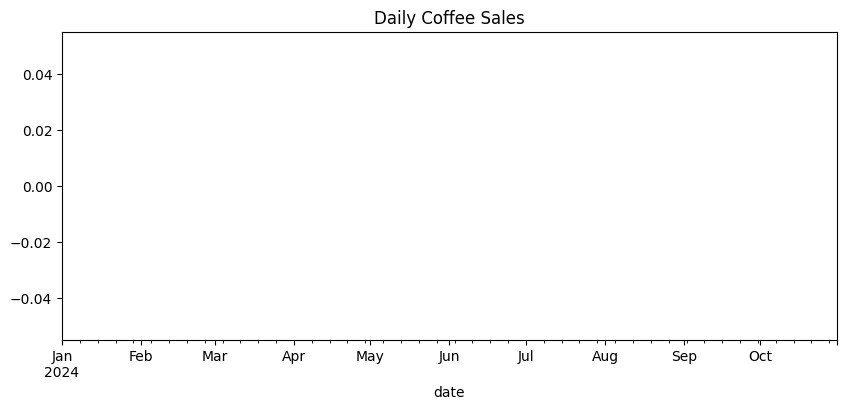

In [14]:
df["sales"].plot(title = "Daily Coffee Sales", figsize=(10,4))
plt.show()

In [12]:
# check rolling mean and variance
rolling_mean = df.rolling(window=30).mean()
rolling_var = df.rolling(window=30).var()

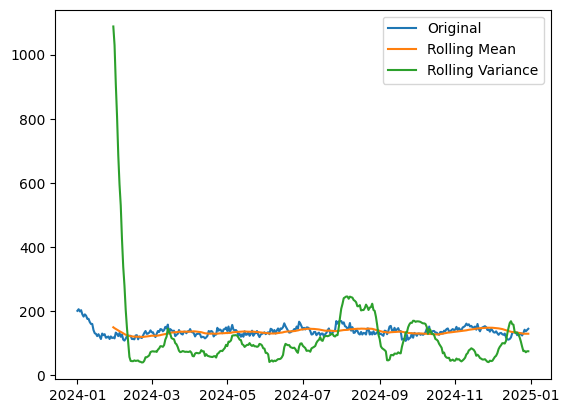

In [13]:
plt.plot(df["daily_coffee_sales"], label= "Original")
plt.plot(rolling_mean, label = "Rolling Mean")
plt.plot(rolling_var, label = "Rolling Variance")
plt.legend()
plt.show()

In [14]:
# stationarity check
from statsmodels.tsa.stattools import adfuller, kpss

In [15]:
result_adf = adfuller(df["daily_coffee_sales"])
result_adf

(np.float64(-5.520489061915514),
 np.float64(1.8824990589106989e-06),
 1,
 363,
 {'1%': np.float64(-3.448493650810824),
  '5%': np.float64(-2.8695352280356556),
  '10%': np.float64(-2.5710293341377715)},
 np.float64(2396.2913199754635))

In [16]:
print(f" p value is: {result_adf[1]}")

 p value is: 1.8824990589106989e-06


In [17]:
print(f" p value is: {result_adf[1]:.10f}")

 p value is: 0.0000018825


In [18]:
kpss(df["daily_coffee_sales"])

C:\Users\amirs\AppData\Local\Temp\ipykernel_11864\2910262905.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss(df["daily_coffee_sales"])


(np.float64(0.06902503630710369),
 np.float64(0.1),
 11,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

In [19]:
# If p-value < 0.05 (ADF) and p-value > 0.05 (KPSS) → series is stationary.
# If not stationary, options:

# Differencing

# Log transform

# Detrending

# Box-Cox transform

In [20]:
# LAG SELECTION
from statsmodels.tsa.ar_model import ar_select_order

In [21]:
selected = ar_select_order(
    df["daily_coffee_sales"],
    maxlag=14,
    ic='aic'
)

print("Selected lags:", selected.ar_lags)

Selected lags: [1, 2]


In [22]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

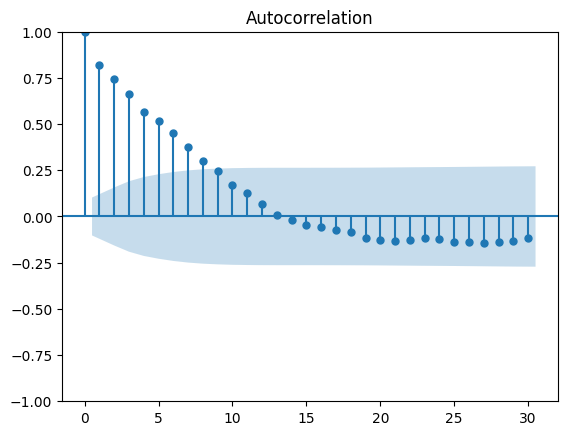

In [23]:
plot_acf(df["daily_coffee_sales"], lags=30)

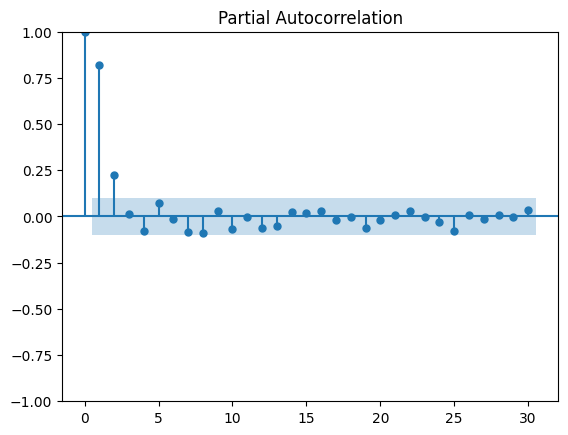

In [24]:
plot_pacf(df["daily_coffee_sales"], lags=30, method="ywm")

In [25]:
# TRAIN-TEST SPLIT
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]["daily_coffee_sales"]
test  = df.iloc[train_size:]["daily_coffee_sales"]

In [26]:
train.shape

(292,)

In [27]:
test.shape

(73,)

In [28]:
# Fit AR Model ONLY on Training Data
from statsmodels.tsa.ar_model import AutoReg

model = AutoReg(
    train,
    lags=selected.ar_lags,
    trend="c",
    old_names=False
)

fit = model.fit()


In [29]:
# Forecast the Test Period
predictions = fit.predict(
    start=test.index[0],
    end=test.index[-1],
    dynamic=False
)


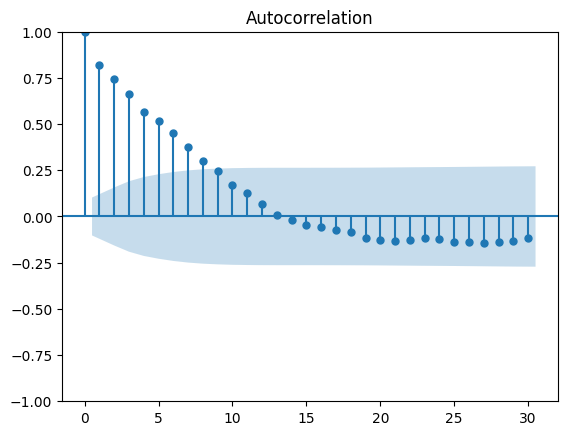

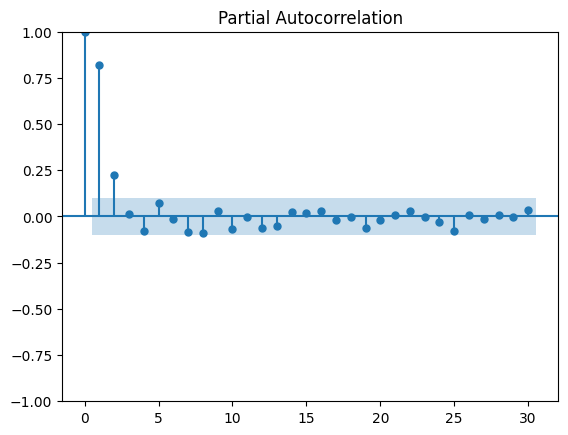

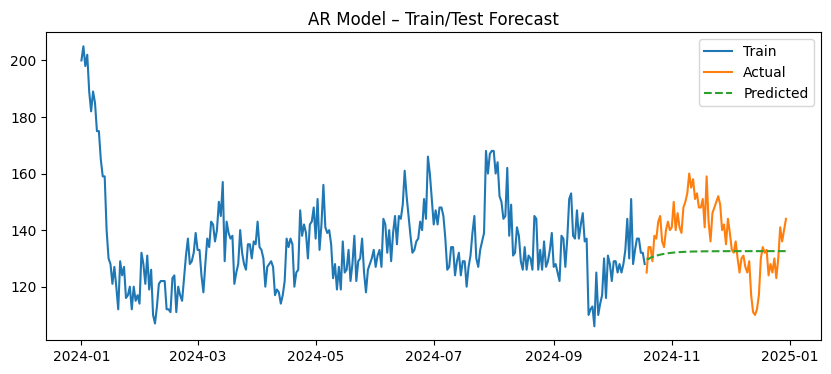

In [30]:
# Compare Actual vs Predicted
plt.figure(figsize=(10,4))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(predictions.index, predictions, label="Predicted", linestyle="--")
plt.legend()
plt.title("AR Model – Train/Test Forecast")
plt.show()

In [31]:
# Numerical Evaluation Metrics
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test, predictions)
print("MAE:", mae)

# 👉 “On average, forecasts are off by X units.”

MAE: 10.152439858809004


In [32]:
# RMSE — Root Mean Squared Error
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, predictions))
print("RMSE:", rmse)


RMSE: 12.407168761510885


In [33]:
# ✔ MAPE — Percentage Error (optional)
mape = np.mean(np.abs((test - predictions) / test)) * 100
print("MAPE:", mape, "%")


MAPE: 7.272947426070919 %


In [34]:
# 5️⃣ Residual Analysis (VERY IMPORTANT FOR AR)
# Residuals tell us whether the AR model captured all time dependence.
residuals = test - predictions
residuals

date
2024-10-19    -4.925195
2024-10-20     4.228446
2024-10-21     3.735957
2024-10-22    -1.484777
2024-10-23     7.248432
                ...    
2024-12-26    -2.570877
2024-12-27     8.429058
2024-12-28     3.429001
2024-12-29     7.428950
2024-12-30    11.428906
Freq: D, Length: 73, dtype: float64

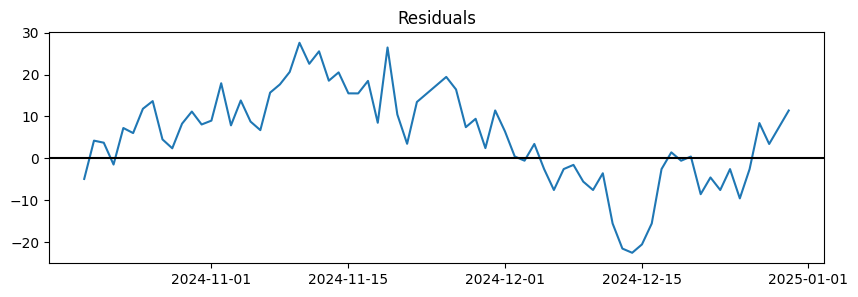

In [35]:
# Residual Plot
plt.figure(figsize=(10,3))
plt.plot(residuals)
plt.title("Residuals")
plt.axhline(0, color="black")
plt.show()


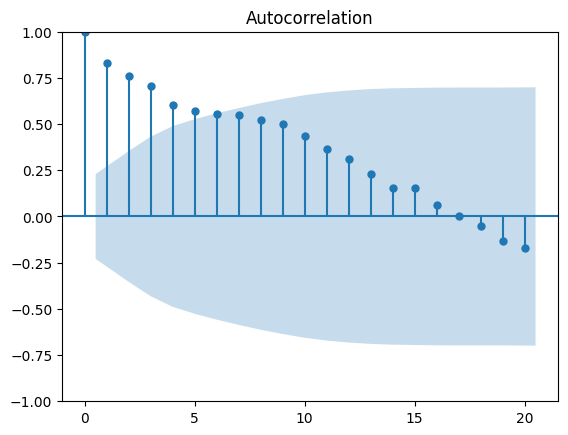

In [36]:
# Autocorrelation of Residuals (CRITICAL)
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals, lags=20)
plt.show()


In [37]:
# Ljung-Box Test (Statistical Confirmation)
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(lb_test)

# ✔ High p-value → residuals behave like white noise
# ❌ Low p-value → model is missing structure

      lb_stat     lb_pvalue
10  302.73758  4.100678e-59
